In [1]:
# Anomaly(Outlier) Detection
# 5 different methods for anomlay detection are used in this jupyter notebook
# (1) Calcuate the mean and standard deviation value, if some data are far away from the mean value
# (2) Cluster data. Assume the 99% data are normal. Pick the 1% data which are at farthest away from the cluster central are otlier
#            Use KMeans and ellow method to find out the suitable number of culsters,
#            Use PCA(Principal component analysis) to reduce the data amount by calculating covariance, eigenvalue (eigenvactor is also caulcated but not used)
#            Use KMeans to cluster the dimension reduced dataset and calcuation the distance beteeen the data point and central of the related cluster
#            the 1% data which at farthest to the cluster centra are anomaly
# (3) Using IsolationForest method
# (4) Oneclass SVM
# (5) EllipticEnvelope for outlier detection of data set with gauss distribution, a very important condition for this method, the data set must be gauss distributed

# This exercise is from https://zhuanlan.zhihu.com/p/668856546

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

In [3]:
# The orginal data was get from https://www.kaggle.com/datasets/vijeetnigam26/expedia-hotel
# The data package was very big. 
# For the learning purpose, the data were slimmed down.
# Only date_time, price_usd, srch_booking_window and srch_saturday_night_bool are taken.

# Load data which have been slimmed down
DataFrame = pd.read_csv("SlimmedDownExpediaData4AnomalyDetection.csv")
print(DataFrame.columns)
print(f'\n')
# Remove the column 'Unnamed: 0'
DataFrame.reindex(['date_time'],axis=1)
DataFrame = DataFrame.drop(['Unnamed: 0'],axis=1)
# Conert data_time(string) to data type
DataFrame['date_time'] = pd.to_datetime(DataFrame['date_time'])
# Sort data by date_time
DataFrame = DataFrame.sort_values('date_time')
DataFrame.info()
print(f'\n')
print(DataFrame.head(5))

Index(['Unnamed: 0', 'date_time', 'price_usd', 'srch_booking_window',
       'srch_saturday_night_bool'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
Index: 3049 entries, 1262 to 1213
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date_time                 3049 non-null   datetime64[ns]
 1   price_usd                 3049 non-null   float64       
 2   srch_booking_window       3049 non-null   int64         
 3   srch_saturday_night_bool  3049 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 119.1 KB


               date_time  price_usd  srch_booking_window  \
1262 2012-11-01 02:48:30       84.0                   19   
22   2012-11-01 03:06:43       78.0                   16   
1074 2012-11-01 09:04:18      114.0                   56   
1633 2012-11-01 09:11:03       76.0                   56   
2201 2012-11-01 10:15

count    3049.000000
mean      112.939023
std       113.374049
min         0.120000
25%        67.000000
50%       100.000000
75%       141.000000
max      5584.000000
Name: price_usd, dtype: float64


count    3048.000000
mean      111.144055
std        55.055161
min         0.120000
25%        67.000000
50%       100.000000
75%       141.000000
max       536.000000
Name: price_usd, dtype: float64


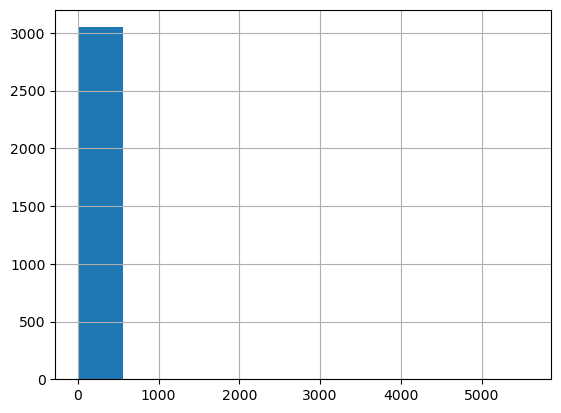

In [4]:
print(DataFrame['price_usd'].describe())
DataFrame['price_usd'].hist()

# The description shows the max price 5584$, but the mean price is only 112.94$
# Obviously the 5584$ is an abnormal data
# Drop data which are higher than 1000$
DataFrame=DataFrame.loc[DataFrame['price_usd']<1000]
print(f'\n')
print(DataFrame['price_usd'].describe())
#only one data is removed data count 3049 -> 3048

<Axes: >

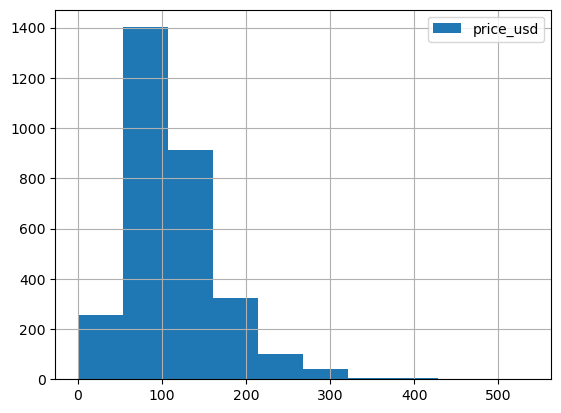

In [5]:
#plot another histogram 
DataFrame['price_usd'].hist(bins=10,legend=True)
#now it looks better

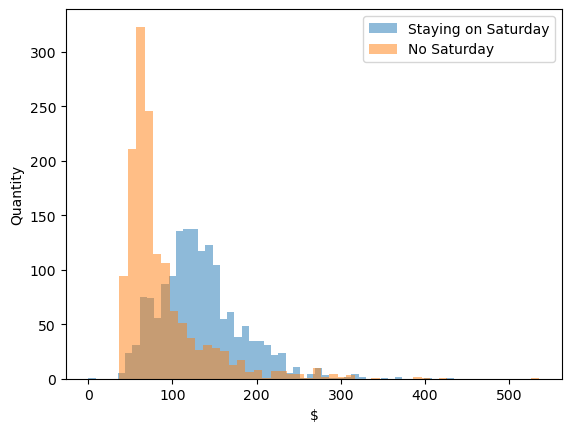

In [6]:
#plot price compare if the stay includes saturday
WithSaturday = DataFrame[DataFrame['srch_saturday_night_bool']==True]['price_usd']
WithoutSaturday = DataFrame[DataFrame['srch_saturday_night_bool']==False]['price_usd']

figure1=plt.figure()
# the attribute alpha is scal value of transparency 
plt.hist(WithSaturday,bins=50, alpha=0.5,label='Staying on Saturday')
plt.hist(WithoutSaturday,bins=50, alpha=0.5,label='No Saturday')
plt.legend()
plt.xlabel('$')
plt.ylabel('Quantity')
plt.show();
#obviously the price is hign with staying on Saturday 


In [7]:
# Using KMeans for clustering the data to find out outliers

# Drop data_time
Data2Clustering = DataFrame.drop(['date_time'],axis=1)

# iterate KMeans method with different number of clusters, with different number of cluster
NoOfCluster = range(1,20)
KM = [KMeans(n_clusters = i, random_state=1).fit(Data2Clustering) for i in NoOfCluster]

# Evaluate the clustering results with the function score
# The function score gives the sum of all distance square value, distance is from the data point to the cluster central.
# Higher score value indicates data points are close to the central. It means a gut clustering
# The score function returns negative value. VERY CONFUSED, close to 0 value indicates rather gut resluts.
Scores = [KM[i].score(Data2Clustering) for i in range(len(KM))]

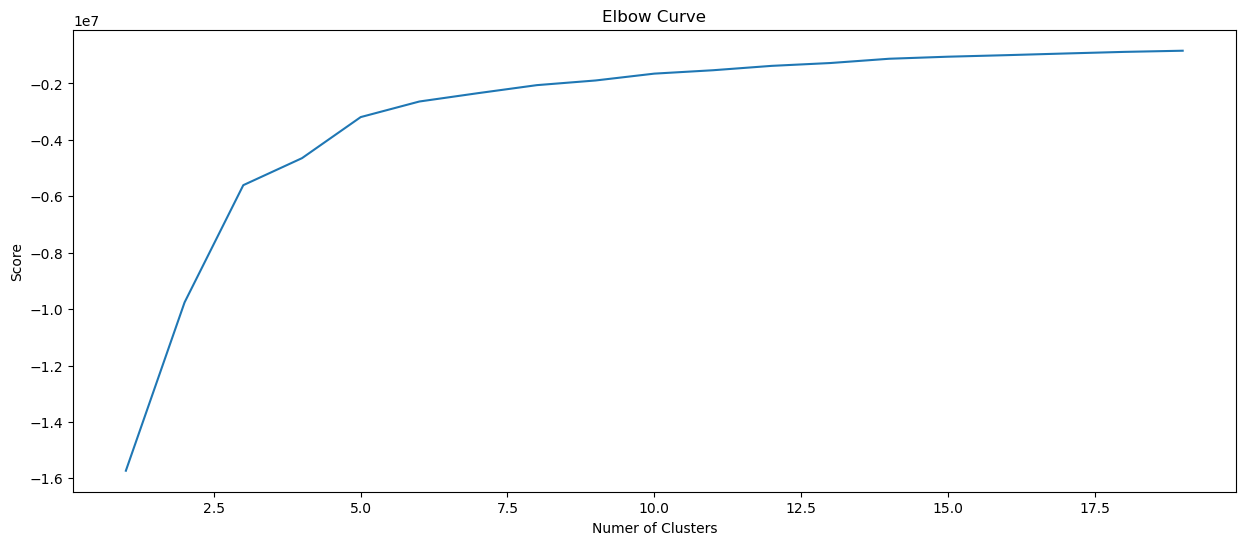

In [8]:
# Plot the score value in relation to the number of clusters
figure2 = plt.figure(figsize=(15,6))
plt.plot(NoOfCluster, Scores)
plt.xlabel('Numer of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()
# The plot shows from 10 clusters the score value are converged 
# This method is named Elbow

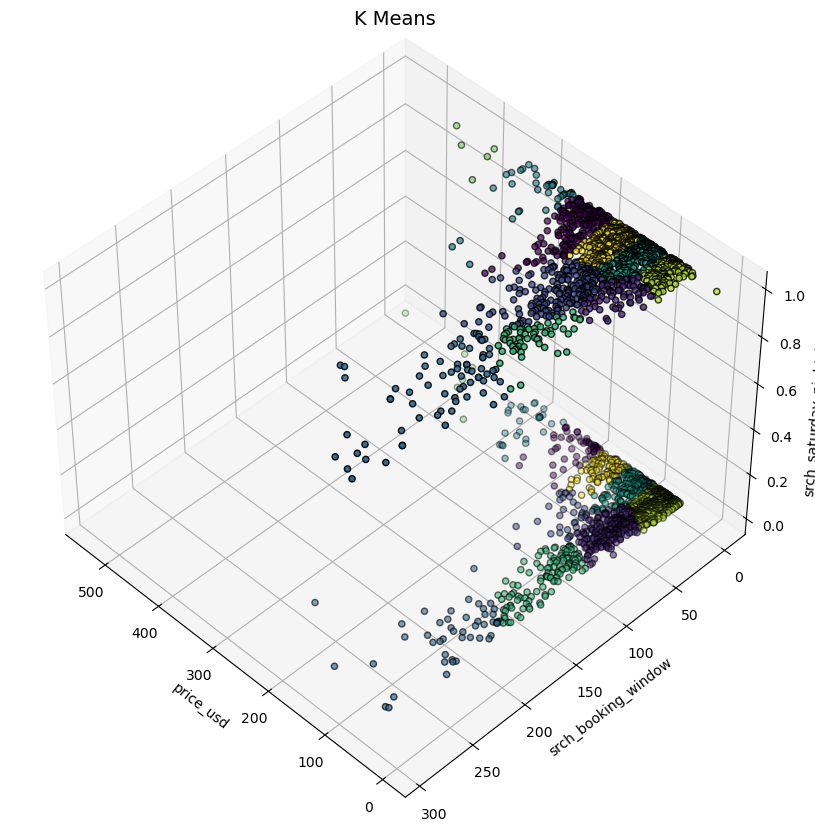

In [9]:
# Cluster data with 10 clusters defined
KM = KMeans(n_clusters=10,random_state=1).fit(Data2Clustering)
Labels = KM.labels_

# Code example how to plot 3d scatter
figure3 = plt.figure(figsize=(10,10))
ax = figure3.add_subplot(projection='3d',elev=45, azim=135)
ax.scatter(Data2Clustering.iloc[:,0], Data2Clustering.iloc[:,1], Data2Clustering.iloc[:,2],
          c=Labels.astype(np.float64), edgecolor="k")

ax.set_xlabel("price_usd")
ax.set_ylabel("srch_booking_window")
ax.set_zlabel("srch_saturday_night_bool")
plt.title("K Means", fontsize=14);

In [10]:
# Cumulative Explained Variance in PCA
# https://medium.com/@megha.natarajan/understanding-cumulative-explained-variance-in-pca-with-python-653e3592a77c

# Standardize data, so that mean = 0, std devation = 1
StdData = StandardScaler().fit_transform(Data2Clustering.values)
print(f'the mean value after standarizing shall be 0. {np.mean(StdData,axis=0)}\n')
print(f'the std devation after standarizing shall be 1. {np.std(StdData,axis=0)}\n')

# Calculate covarianz
Covari = np.cov(StdData.T)
print(f'covarianc:\n {Covari}\n\n') #the value of the diagnoal shall be 1

# Calculate the eigenvalues and eigenvectors of the variance matrix
EigV, EigVector = np.linalg.eig(Covari) # the eigentvectors is not needed really
print( f'eigenvalues: \n {EigV}\n\neigenvectors:\n {EigVector}|\n' )

# The eigenvalue will be sorted at next stpe, to keep the eigentvalue and eigenvector together, a list is built as below
EigVPairs = [ (np.abs(EigV[i]),EigVector[:,i]) for i in range(len(EigV))]
print(f'{EigVPairs}\n\n')

# Sort by the eigenvalue(by first value of each array element
EigVPairs.sort(key = lambda x: x[0], reverse= True)
print(f'{EigVPairs}\n\n')

# Calculate explained variance, the total value shall be 100% therefor the 1st step
SumEigV = sum(EigV)
VarExp = [(i/SumEigV)*100 for i in sorted(EigV, reverse=True)] 
print(f'{VarExp}\n')

#calculate cumulative explained variance 
cum_var_exp = np.cumsum(VarExp)
print(f'{cum_var_exp}\n')



the mean value after standarizing shall be 0. [ 3.72988313e-16 -3.49676543e-17 -4.66235391e-18]

the std devation after standarizing shall be 1. [1. 1. 1.]

covarianc:
 [[ 1.00032819 -0.06464936  0.41098219]
 [-0.06464936  1.00032819  0.02234168]
 [ 0.41098219  0.02234168  1.00032819]]


eigenvalues: 
 [0.58031429 1.41350081 1.00716948]

eigenvectors:
 [[-0.70329412 -0.70906231 -0.0510688 ]
 [-0.14526912  0.07302271  0.98669376]
 [ 0.69589817 -0.70135463  0.1543613 ]]|

[(0.5803142857748973, array([-0.70329412, -0.14526912,  0.69589817])), (1.4135008099167155, array([-0.70906231,  0.07302271, -0.70135463])), (1.007169479300184, array([-0.0510688 ,  0.98669376,  0.1543613 ]))]


[(1.4135008099167155, array([-0.70906231,  0.07302271, -0.70135463])), (1.007169479300184, array([-0.0510688 ,  0.98669376,  0.1543613 ])), (0.5803142857748973, array([-0.70329412, -0.14526912,  0.69589817]))]


[47.101235431061134, 33.56130143731036, 19.337463131628514]

[ 47.10123543  80.66253687 100.        ]

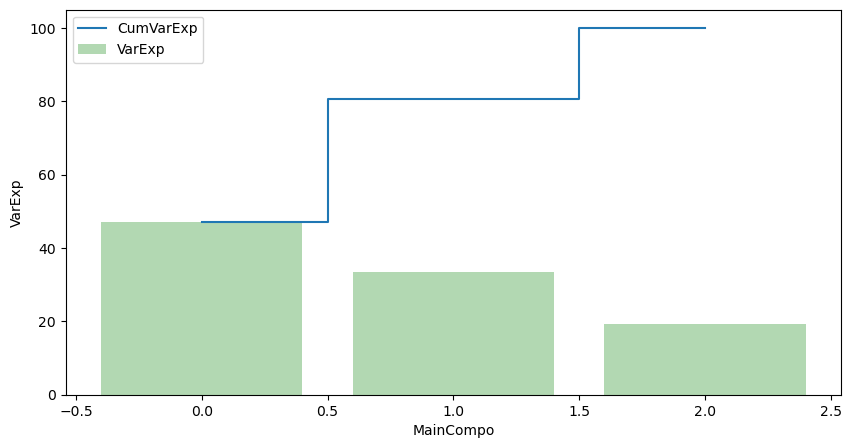

In [11]:
# As the diagram below shows
# The main component(1st) has round about 50% correlation with other components, the 2nd component has 30%.
# Therefor reduce the component to 2 with PCA(Principal Component Analysis)

plt.figure(figsize=(10, 5))
plt.bar(range(len(VarExp)), VarExp, alpha=0.3, align='center', label='VarExp', color = 'g')
plt.step(range(len(cum_var_exp)), cum_var_exp, where='mid',label='CumVarExp')
plt.ylabel('VarExp')
plt.xlabel('MainCompo')
plt.legend(loc='best')
plt.show();

[-6096.000000000002, -3668.402439120234, -1839.0695484232501, -1520.3573521208632, -1211.219715852011, -918.9842384854219, -808.2412535721303, -689.3868663987821, -576.8704053973285, -528.4848801106856, -490.7283027983087, -425.0718693228119, -396.8510546358749, -368.22396334905045, -340.69886408122443, -315.7361761209245, -292.36450750295495, -273.27242561974504, -257.500770918325]


            date_time  price_usd  srch_booking_window  \
0 2012-11-01 02:48:30       84.0                   19   
1 2012-11-01 03:06:43       78.0                   16   
2 2012-11-01 09:04:18      114.0                   56   
3 2012-11-01 09:11:03       76.0                   56   
4 2012-11-01 10:15:25      128.0                    0   

   srch_saturday_night_bool  Cluster  PCAFeature1  PCAFeature2  
0                         0        6    -0.889864    -0.521900  
1                         1        1     0.230566    -0.272218  
2                         1        7     0.567439     0.546642  
3        

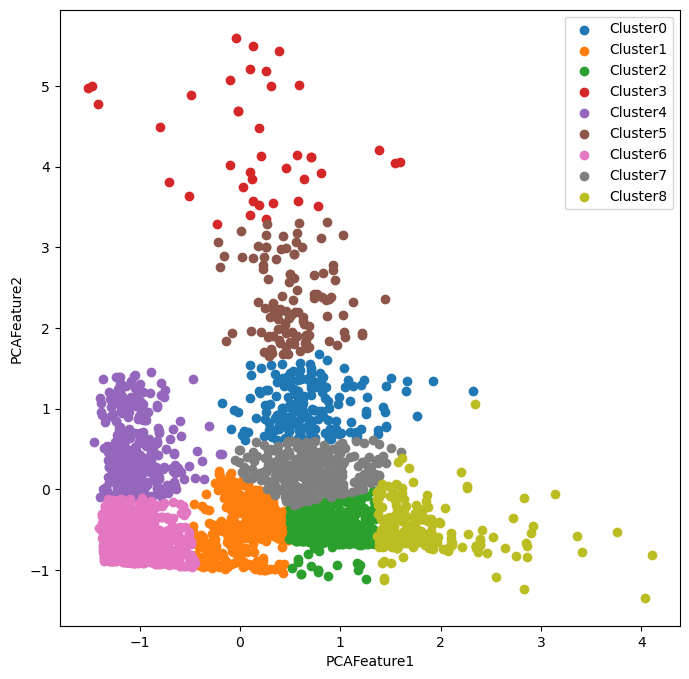

In [12]:
PCAData = PCA(n_components = 2).fit_transform(StdData)

# Standarizing the PCAData once again. is it necessary?
StdPCAData = StandardScaler().fit_transform(PCAData)
#print(np.mean(StdPCAData,axis=0))
#print(np.std(StdPCAData,axis=0))

NewDataFrame = pd.DataFrame(StdPCAData)

# Use Elbow method once
KM = [KMeans(n_clusters=i,random_state=4).fit(NewDataFrame) for i in NoOfCluster]
Scores = [KM[i].score(NewDataFrame) for i in range(len(KM))]
print(Scores)
print(f'\n')

# Data shall be clustered in 10 gruppe
DataFrame['Cluster'] = KM[9].predict(NewDataFrame)

#expand the data frame for using late on
NewDataFrame['Cluster'] = KM[9].labels_
DataFrame.index = NewDataFrame.index
DataFrame['PCAFeature1'] = NewDataFrame[0]
DataFrame['PCAFeature2'] = NewDataFrame[1]
print(DataFrame.head())

LegendList = []
figure4 = plt.figure(figsize=(8,8))
for i in range (0,9):
    plt.scatter(DataFrame['PCAFeature1'][DataFrame['Cluster'] == np.int32(i)],
            DataFrame['PCAFeature2'][DataFrame['Cluster'] == np.int32(i)])
    LegendList.append(f'Cluster{i}')
    
plt.xlabel('PCAFeature1')
plt.ylabel('PCAFeature2')
plt.legend(LegendList)


In [13]:
# define function calcuate the distance between each data point and the cluster central
def CalDistanceByPoint(Data,KMMdl):
    distance =[]
    for i in range(0,len(Data)):
        x = np.array(Data.loc[i,0:1])
        y = KMMdl.cluster_centers_[Data.loc[i,'Cluster']]  
        distance.append(np.linalg.norm(x-y))
    return distance    

Anomaly1
False    3017
True       31
Name: count, dtype: int64


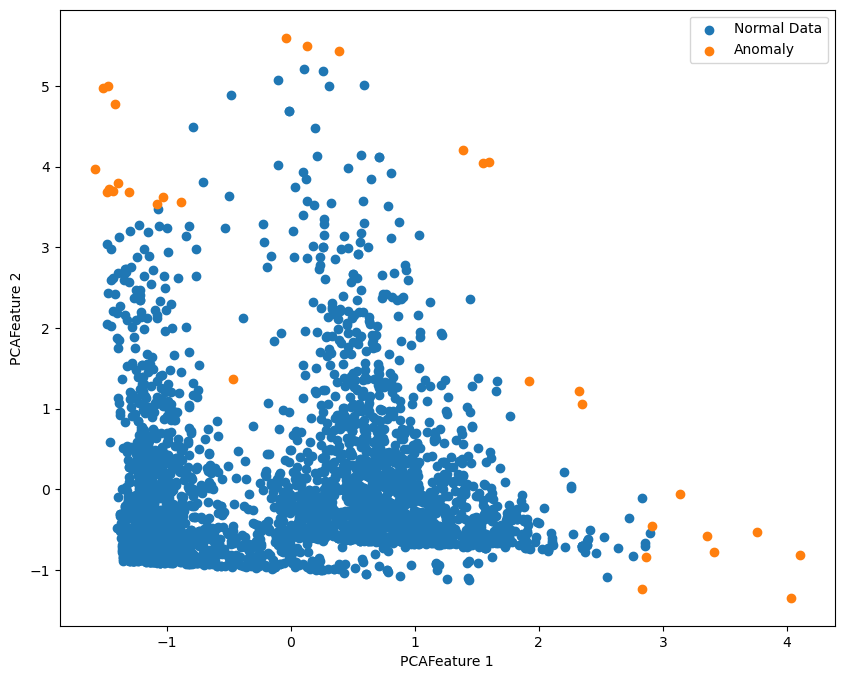

In [14]:
Distance = CalDistanceByPoint(NewDataFrame,KM[9])
Distance = np.array(Distance)
#print(Distance)

# Calculate the threshold
# Define outlier fraction, assume 99% data are normal, only 1 % data are outlier
OutliersFrac = 0.99 
NumberOfNormalData = int(OutliersFrac*len(Distance))

# Using argsort function to get the index of the highst NumberOfNormalData
Idx = Distance.argsort()[NumberOfNormalData:]
Thold = Distance[Idx].min()
DataFrame['Anomaly1'] = (Distance>=Thold).astype(bool)

figure5 = plt.figure(figsize=(10,8))
plt.scatter(DataFrame['PCAFeature1'][~DataFrame['Anomaly1']],
            DataFrame['PCAFeature2'][~DataFrame['Anomaly1']], label='Normal Data')

plt.scatter(DataFrame['PCAFeature1'][DataFrame['Anomaly1']],
            DataFrame['PCAFeature2'][DataFrame['Anomaly1']], label = 'Anomaly')
plt.xlabel('PCAFeature 1')
plt.ylabel('PCAFeature 2')
plt.legend()

print(DataFrame.Anomaly1.value_counts())

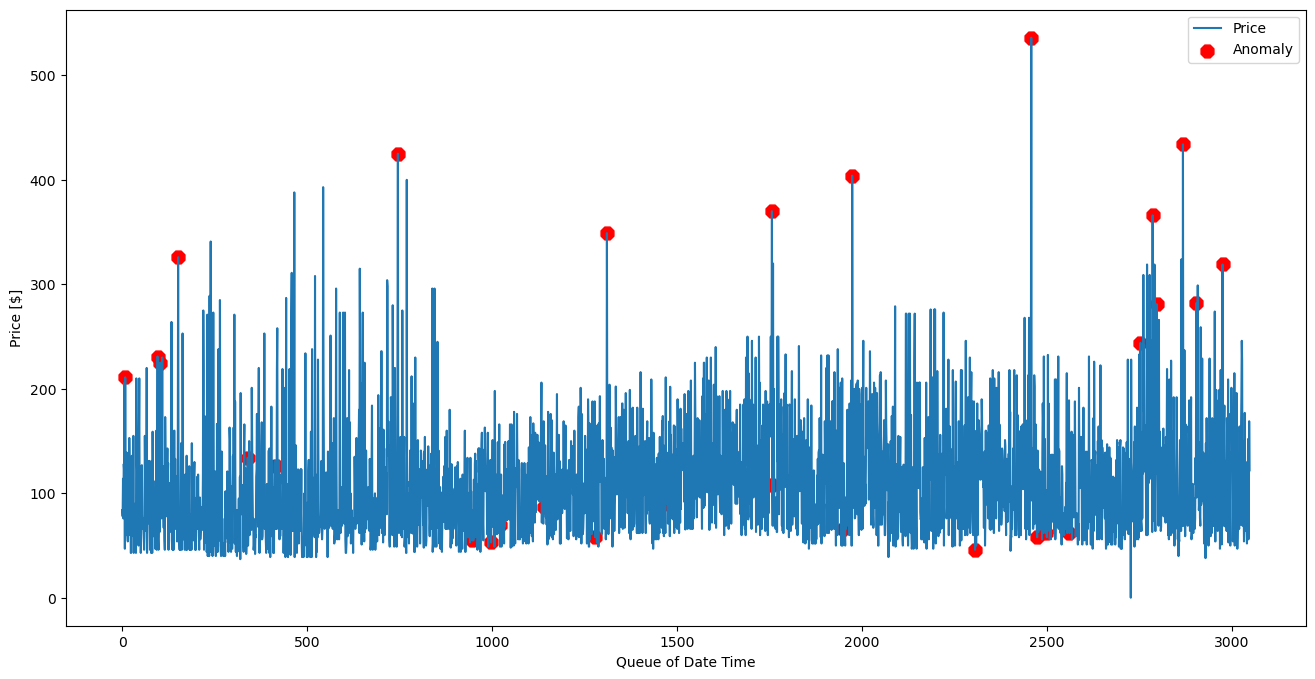

In [15]:
# The plot below shows
# The anomaly data points (price) detected with KMeans and PCA are in the highest and lowest price section mostly

SortData = DataFrame.sort_values('date_time')
Idx = SortData.index[SortData['Anomaly1']].tolist()

figure6 = plt.figure(figsize=(16,8))
plt.plot(list(range(0,len(SortData))), SortData['price_usd'],label='Price')
plt.scatter(Idx, SortData['price_usd'][SortData['Anomaly1']],color='red',marker = '8', s=100,label='Anomaly')
plt.xlabel("Queue of Date Time")
plt.ylabel('Price [$]')
plt.legend()
plt.show()



In [16]:
# Isolationforest method
# Create new data frame by drop data_time. It is same as Data2Clustering
DataFrame4IsolationForest = DataFrame[['price_usd', 'srch_booking_window', 'srch_saturday_night_bool']]
# Standarize the data
StdData = StandardScaler().fit_transform(DataFrame4IsolationForest)
StdData = pd.DataFrame(StdData)
print(type(StdData))

# Creat isolationforest model 
IsolationForestMdl = IsolationForest(contamination=(1-OutliersFrac)).fit(StdData)
OutlierResults = IsolationForestMdl.predict(StdData)
DataFrame['Anomaly2'] = OutlierResults
print(print(DataFrame.Anomaly2.value_counts()))


<class 'pandas.core.frame.DataFrame'>
Anomaly2
 1    3017
-1      31
Name: count, dtype: int64
None


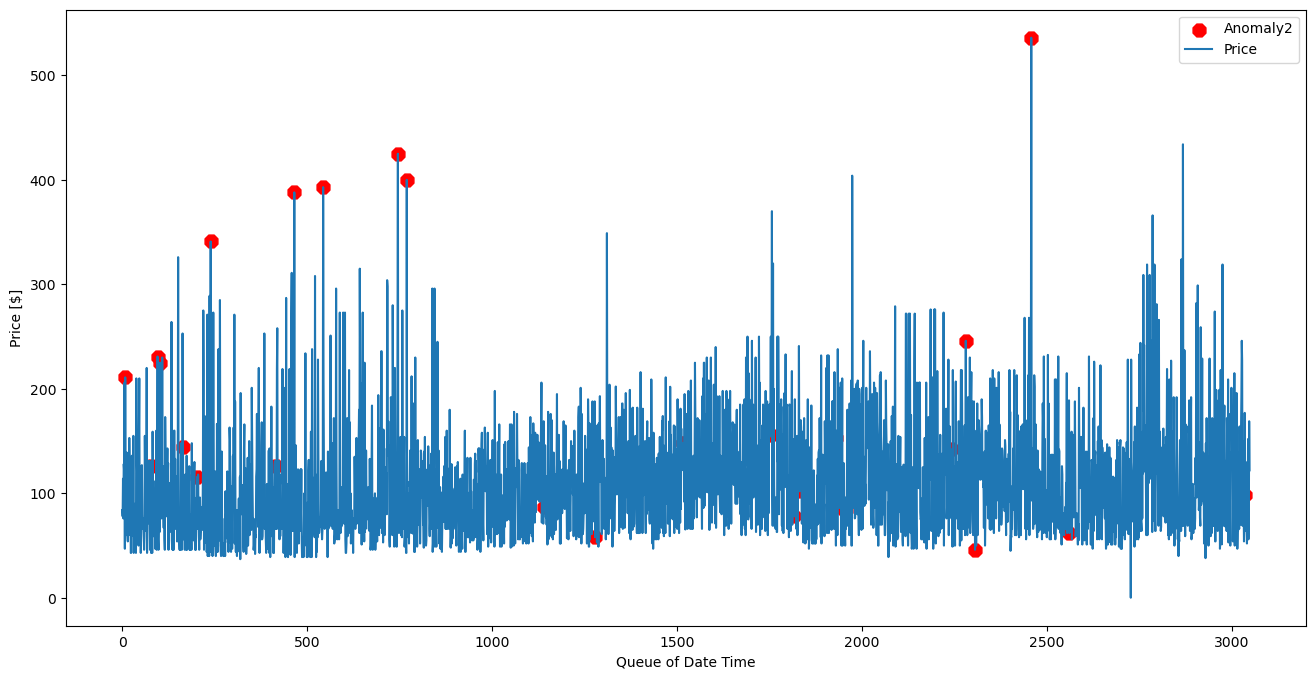

In [17]:
SortData = DataFrame.sort_values('date_time')
figure7 = plt.figure(figsize=(16,8))
Idx = SortData.index[SortData['Anomaly2']==-1].tolist()

plt.scatter(Idx, SortData['price_usd'][SortData['Anomaly2']==-1],color='red',marker = '8', s=100,label='Anomaly2')
plt.plot(list(range(0,len(SortData))), SortData['price_usd'],label='Price')
plt.xlabel("Queue of Date Time")
plt.ylabel('Price [$]')
plt.legend()
plt.show()

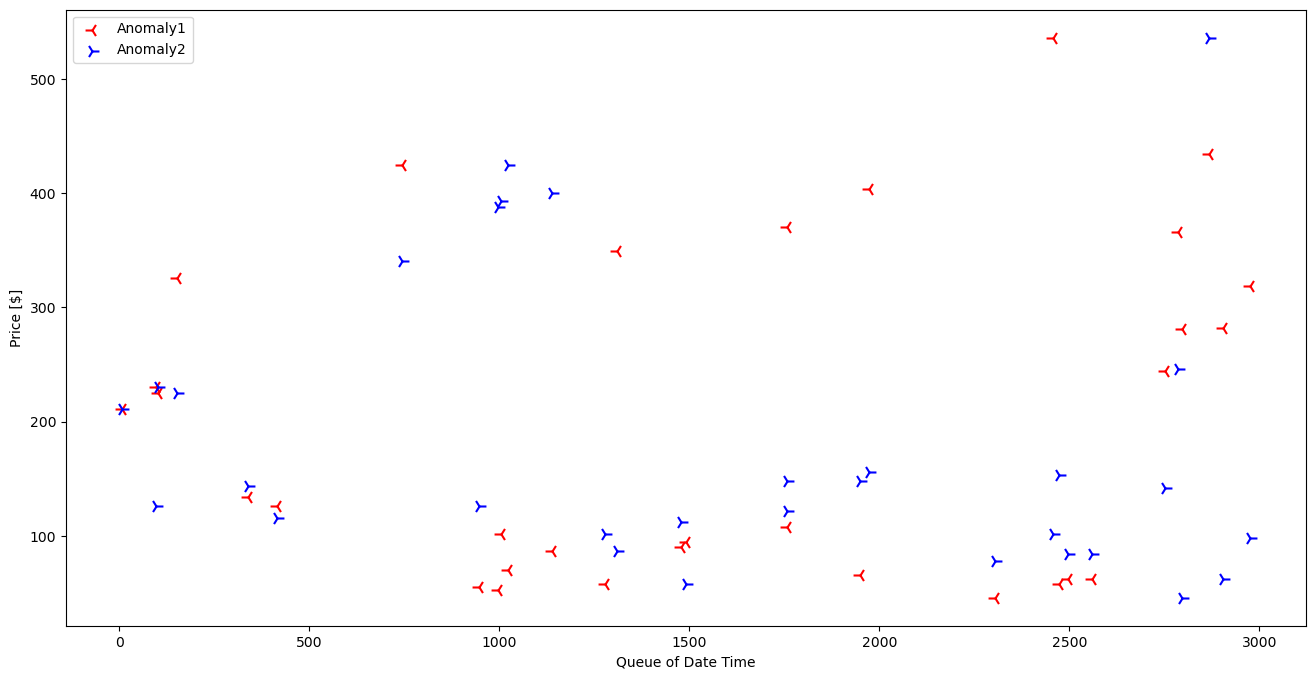

In [18]:
figure8 = plt.figure(figsize=(16,8))
IdxAnomaly1 = SortData.index[SortData['Anomaly1']].tolist()
IdxAnomaly2 = SortData.index[SortData['Anomaly2']==-1].tolist()

plt.scatter(IdxAnomaly1, SortData['price_usd'][SortData['Anomaly1']],color='red',marker = '3', s=100,label='Anomaly1')
plt.scatter(IdxAnomaly1, SortData['price_usd'][SortData['Anomaly2']==-1],color='blue',marker = '4', s=100,label='Anomaly2')
plt.xlabel("Queue of Date Time")
plt.ylabel('Price [$]')
plt.legend()
plt.show()

In [19]:
print(len(IdxAnomaly1), len(IdxAnomaly2))

31 31


Anomaly3
 1    3017
-1      31
Name: count, dtype: int64
None


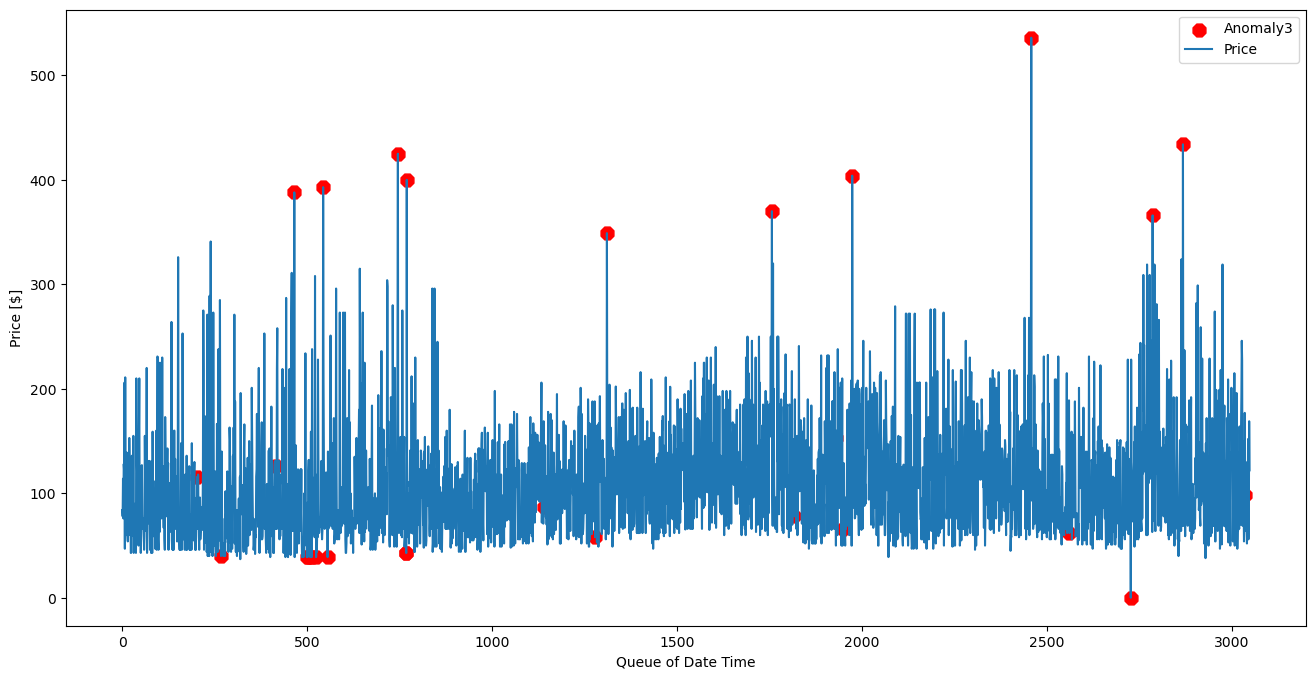

In [20]:
# OneClassSVM
# Create new data frame by drop data_time. It is same as Data2Clustering
DataFrame4OneClassSVM = DataFrame[['price_usd', 'srch_booking_window', 'srch_saturday_night_bool']]
# Standarize the data
StdData = StandardScaler().fit_transform(DataFrame4OneClassSVM)
#convert to pandas data frame
StdData = pd.DataFrame(StdData)

# Creat OnceClassSVM model and calculate the Anomaly
DataFrame['Anomaly3'] = OneClassSVM(nu=(1-OutliersFrac), kernel="rbf", gamma=0.01).fit_predict(StdData)

print(print(DataFrame.Anomaly3.value_counts()))

figure9 = plt.figure(figsize=(16,8))
SortData = DataFrame.sort_values('date_time')
IdxAnomaly3 = SortData.index[SortData['Anomaly3']==-1].tolist()

plt.scatter(IdxAnomaly3, SortData['price_usd'][SortData['Anomaly3']==-1],color='red',marker = '8', s=100,label='Anomaly3')
plt.plot(list(range(0,len(SortData))), SortData['price_usd'],label='Price')
plt.xlabel("Queue of Date Time")
plt.ylabel('Price [$]')
plt.legend()
plt.show()


In [21]:
# The pre conditon of using gauss distribution for anomaly detection is that the data has normal distribution. 

# Using EllipticEnvelope, object for detecting outliers in a Gaussian distributed dataset. 

# The dataset is splited in two parts
Class0 = DataFrame.loc[DataFrame['srch_saturday_night_bool'] == 0, 'price_usd']
Class0Train = Class0.values.reshape(-1,1)
Class0 = pd.DataFrame(Class0)
Class0['Anomaly'] =  EllipticEnvelope(contamination = (1-OutliersFrac)).fit_predict(Class0Train)

Class1 = DataFrame.loc[DataFrame['srch_saturday_night_bool'] == 1, 'price_usd']
Class1Train = Class1.values.reshape(-1,1)
Class1 = pd.DataFrame(Class1)
Class1['Anomaly'] =  EllipticEnvelope(contamination = (1-OutliersFrac)).fit_predict(Class1Train)

# Add results back to the DataFrame
OutlierClass = pd.concat([Class0, Class1])
print(OutlierClass.head())
DataFrame['Anomaly4'] = OutlierClass['Anomaly']

    price_usd  Anomaly
0        84.0        1
7        47.0        1
17       98.0        1
21       60.0        1
23       43.0        1


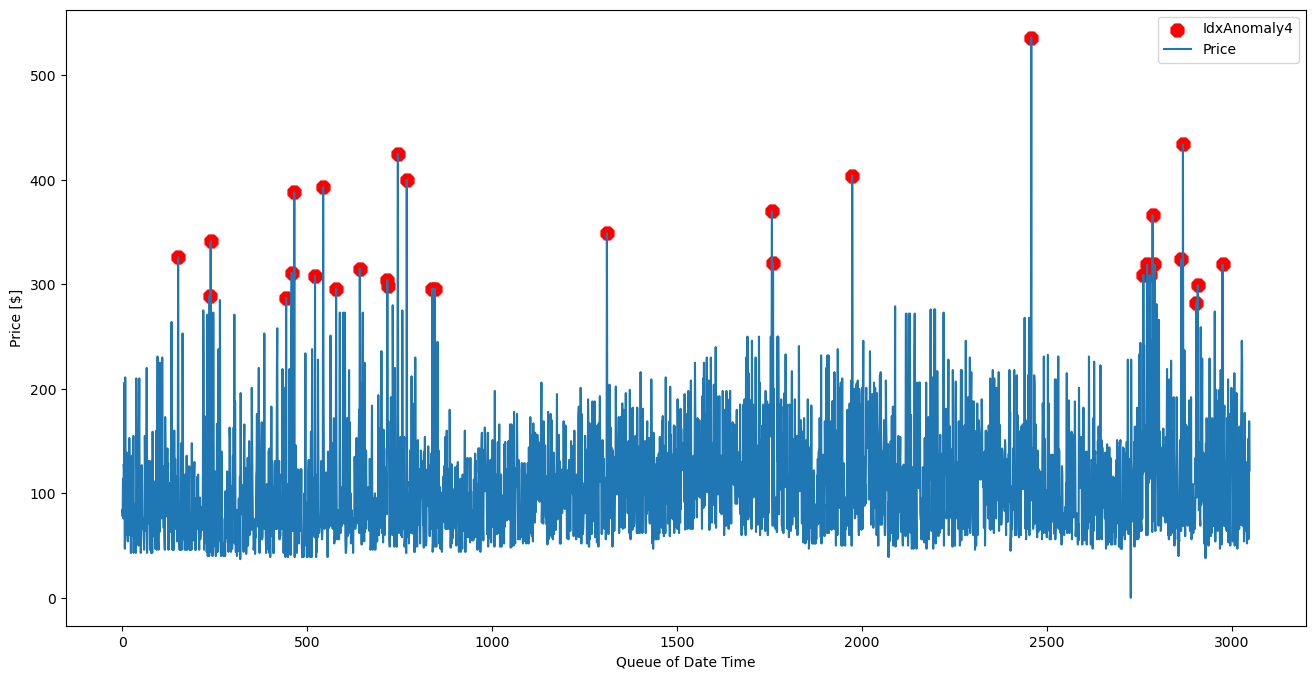

In [22]:
# This method found only outlier in high price range
figure10 = plt.figure(figsize=(16,8))
SortData = DataFrame.sort_values('date_time')
IdxAnomaly4 = SortData.index[SortData['Anomaly4']==-1].tolist()

plt.scatter(IdxAnomaly4, SortData['price_usd'][SortData['Anomaly4']==-1],color='red',marker = '8', s=100,label='IdxAnomaly4')
plt.plot(list(range(0,len(SortData))), SortData['price_usd'],label='Price')
plt.xlabel("Queue of Date Time")
plt.ylabel('Price [$]')
plt.legend()
plt.show()

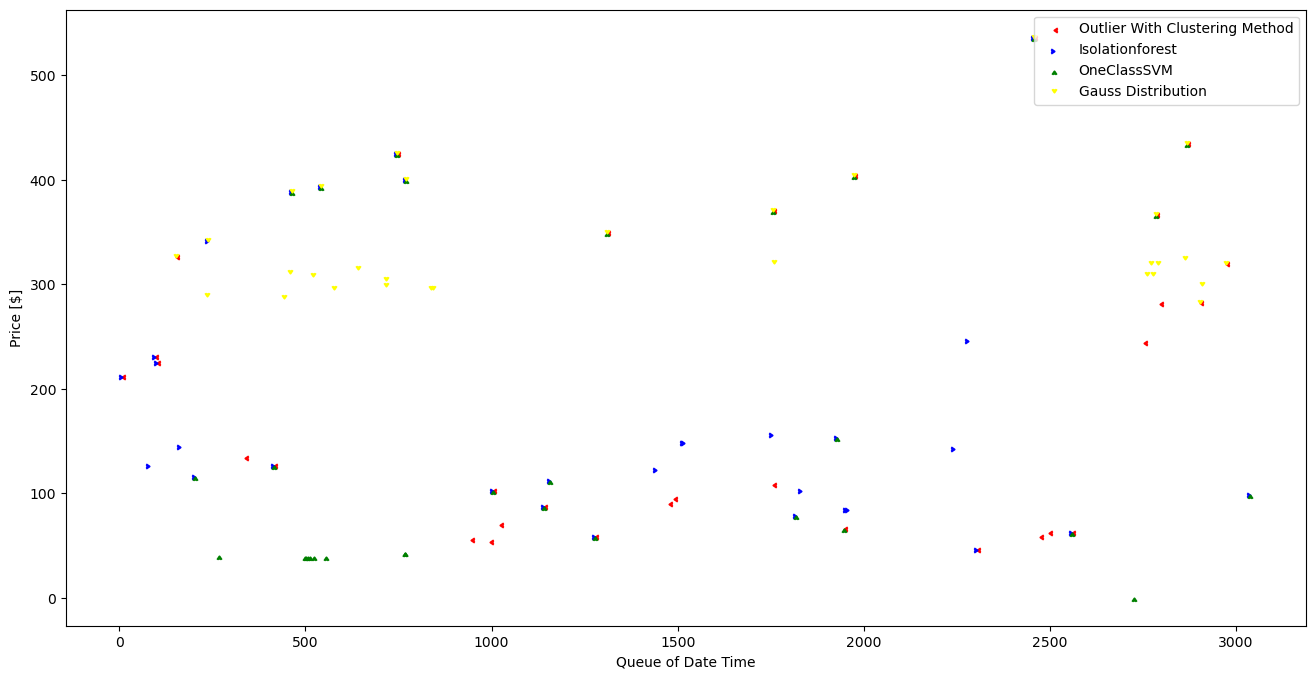

In [23]:
figure11 = plt.figure(figsize=(16,8))
IdxAnomaly1 = SortData.index[SortData['Anomaly1']].tolist()
IdxAnomaly2 = SortData.index[SortData['Anomaly2']==-1].tolist()
IdxAnomaly3 = SortData.index[SortData['Anomaly3']==-1].tolist()
IdxAnomaly4 = SortData.index[SortData['Anomaly4']==-1].tolist()

plt.scatter(IdxAnomaly1, SortData['price_usd'][SortData['Anomaly1']],color='red',marker = 4, s=10,label='Outlier With Clustering Method')
plt.scatter(IdxAnomaly2, SortData['price_usd'][SortData['Anomaly2']==-1],color='blue',marker = 5, s=10,label='Isolationforest')
plt.scatter(IdxAnomaly3, SortData['price_usd'][SortData['Anomaly3']==-1],color='green',marker = 6, s=10,label='OneClassSVM')
plt.scatter(IdxAnomaly4, SortData['price_usd'][SortData['Anomaly4']==-1],color='yellow',marker = 7, s=10,label='Gauss Distribution')
plt.xlabel("Queue of Date Time")
plt.ylabel('Price [$]')
plt.legend()
plt.show()